<a href="https://colab.research.google.com/github/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego/blob/yolo26/notebooks/06_entrenamiento_YOLO26s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 - Entrenamiento YOLO26s para detección de humo y fuego

En este notebook se entrena un modelo **YOLO26s** sobre el dataset D-Fire, manteniendo el mismo conjunto de datos y protocolo de evaluación utilizado en los experimentos anteriores.

El objetivo es incorporar un modelo YOLO de mayor capacidad y comparar posteriormente su desempeño con YOLOv8n, YOLO11n, Faster R-CNN y RT-DETR.

## Salidas esperadas

El entrenamiento genera:

- pesos del modelo (`best.pt` y `last.pt`);
- métricas de entrenamiento y validación;
- curvas de desempeño;
- matriz de confusión;
- predicciones sobre el conjunto de validación;
- configuración utilizada en el experimento;
- carpeta de resultados asociada al experimento.

In [1]:
# ============================================================
# Setup general del entorno
# ============================================================

from pathlib import Path
import os
import sys
import random
import shutil
import time
import yaml

SEED = 42
random.seed(SEED)

IN_COLAB = "google.colab" in sys.modules

print("Ejecutando en Google Colab:", IN_COLAB)
print("Directorio actual:", Path.cwd())

Ejecutando en Google Colab: True
Directorio actual: /content


In [2]:
# ============================================================
# Configuración del repositorio
# ============================================================

REPO_URL = "https://github.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego.git"
REPO_NAME = "VpC2---Deteccion-de-humo-y-fuego"
BRANCH_NAME = "yolo26"

In [3]:
# ============================================================
# Instalación de dependencias
# ============================================================

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego/main/requirements.txt

print("Dependencias instaladas.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.9 MB/s eta 0:00:00
Dependencias instaladas.


In [4]:
# ============================================================
# Verificación de GPU
# ============================================================

import torch

print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. Para entrenar se recomienda activar GPU en Colab.")

CUDA disponible: True
GPU: Tesla T4


In [5]:
# ============================================================
# Montar Google Drive
# ============================================================

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/VCII_DFire")
DRIVE_RUNS_DIR = DRIVE_PROJECT_DIR / "runs"
DRIVE_RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta principal en Drive:", DRIVE_PROJECT_DIR)
print("Carpeta de corridas:", DRIVE_RUNS_DIR)

Mounted at /content/drive
Carpeta principal en Drive: /content/drive/MyDrive/VCII_DFire
Carpeta de corridas: /content/drive/MyDrive/VCII_DFire/runs


In [6]:
# ============================================================
# Clonado o actualización del repositorio
# ============================================================

PROJECT_DIR = Path("/content") / REPO_NAME

if IN_COLAB:

    if (PROJECT_DIR / ".git").exists():

        print("Repositorio encontrado. Actualizando...")
        %cd {PROJECT_DIR}

        !git fetch origin
        !git checkout {BRANCH_NAME}
        !git pull origin {BRANCH_NAME}

    else:

        print("Clonando repositorio...")
        %cd /content

        # Eliminamos una carpeta incompleta de intentos anteriores
        if PROJECT_DIR.exists():
            shutil.rmtree(PROJECT_DIR)

        !git clone --branch {BRANCH_NAME} {REPO_URL}

        %cd {PROJECT_DIR}

print("\n" + "=" * 60)
print("Repositorio listo")
print("=" * 60)

print("PROJECT_DIR:", PROJECT_DIR)

print("\nBranch actual:")
!git branch --show-current

print("\nEstado de Git:")
!git status --short

Clonando repositorio...
/content
Cloning into 'VpC2---Deteccion-de-humo-y-fuego'...
remote: Enumerating objects: 555, done.
remote: Counting objects: 100% (555/555), done.
remote: Compressing objects: 100% (317/317), done.
remote: Total 555 (delta 302), reused 409 (delta 210), pack-reused 0 (from 0)
Receiving objects: 100% (555/555), 19.53 MiB | 19.57 MiB/s, done.
Resolving deltas: 100% (302/302), done.
/content/VpC2---Deteccion-de-humo-y-fuego

Repositorio listo
PROJECT_DIR: /content/VpC2---Deteccion-de-humo-y-fuego

Branch actual:
yolo26

Estado de Git:


In [7]:
# ============================================================
# Verificación de estructura del proyecto
# ============================================================

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

print("Notebooks disponibles:\n")

for notebook in sorted(NOTEBOOKS_DIR.glob("*.ipynb")):
    print(" -", notebook.name)

Notebooks disponibles:

 - 01_exploracion_dfire.ipynb
 - 02_entrenamiento_YOLO.ipynb
 - 02_entrenamiento_YOLO8n_50epochs.ipynb
 - 06_entrenamiento_YOLO26s.ipynb


## Configuración del experimento

Los hiperparámetros del entrenamiento se almacenan en un archivo YAML independiente para mantener el notebook reproducible y facilitar la comparación entre experimentos.

En esta primera prueba se utiliza **YOLO26s** manteniendo los mismos parámetros generales utilizados en el baseline YOLOv8n. De esta manera, la principal variable experimental es la arquitectura del modelo.

In [8]:
# ============================================================
# Creación de la configuración del experimento
# ============================================================

CONFIG_DIR = PROJECT_DIR / "configs" / "experiments"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG_PATH = CONFIG_DIR / "yolo26s_baseline.yaml"

experiment_config = {
    "experiment": {
        "name": "yolo26s_baseline",
        "family": "YOLO26",
        "model": "yolo26s.pt",
        "description": "Baseline con YOLO26 small sobre D-Fire."
    },

    "training": {
        "epochs": 50,
        "imgsz": 640,
        "batch": 16,
        "patience": 10,
        "optimizer": "auto",
        "lr0": 0.01,
        "seed": 42
    },

    "output": {
        "project": "/content/drive/MyDrive/VCII_DFire/runs",
        "save_weights": True
    }
}

with open(EXPERIMENT_CONFIG_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        experiment_config,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("Configuración creada en:")
print(EXPERIMENT_CONFIG_PATH)

Configuración creada en:
/content/VpC2---Deteccion-de-humo-y-fuego/configs/experiments/yolo26s_baseline.yaml


In [9]:
# ============================================================
# Verificación de la configuración
# ============================================================

with open(EXPERIMENT_CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print(yaml.safe_dump(
    config,
    sort_keys=False,
    allow_unicode=True
))

experiment:
  name: yolo26s_baseline
  family: YOLO26
  model: yolo26s.pt
  description: Baseline con YOLO26 small sobre D-Fire.
training:
  epochs: 50
  imgsz: 640
  batch: 16
  patience: 10
  optimizer: auto
  lr0: 0.01
  seed: 42
output:
  project: /content/drive/MyDrive/VCII_DFire/runs
  save_weights: true



In [10]:
# ============================================================
# Carga de parámetros del experimento
# ============================================================

EXP_NAME = config["experiment"]["name"]
MODEL_NAME = config["experiment"]["model"]

EPOCHS = config["training"]["epochs"]
IMGSZ = config["training"]["imgsz"]
BATCH = config["training"]["batch"]
PATIENCE = config["training"]["patience"]
OPTIMIZER = config["training"]["optimizer"]
LR0 = config["training"]["lr0"]
SEED = config["training"]["seed"]

OUTPUT_PROJECT = Path(config["output"]["project"])

print("Experimento :", EXP_NAME)
print("Modelo      :", MODEL_NAME)
print("Epochs      :", EPOCHS)
print("Image size  :", IMGSZ)
print("Batch       :", BATCH)
print("Seed        :", SEED)
print("Salida      :", OUTPUT_PROJECT)

Experimento : yolo26s_baseline
Modelo      : yolo26s.pt
Epochs      : 50
Image size  : 640
Batch       : 16
Seed        : 42
Salida      : /content/drive/MyDrive/VCII_DFire/runs


In [11]:
# ============================================================
# Localización del dataset D-Fire
# ============================================================

import kagglehub

DATASET_ID = "sayedgamal99/smoke-fire-detection-yolo"

dataset_root = Path(
    kagglehub.dataset_download(DATASET_ID)
)

DATA_DIR = dataset_root / "data"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATA_DIR}"
    )

print("Dataset D-Fire:")
print(DATA_DIR)

Using Colab cache for faster access to the 'smoke-fire-detection-yolo' dataset.
Dataset D-Fire:
/kaggle/input/smoke-fire-detection-yolo/data


In [12]:
# ============================================================
# Configuración del dataset para YOLO
# ============================================================

DFIRE_YAML = Path("/content/dfire_colab.yaml")

dfire_config = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 2,
    "names": {
        0: "smoke",
        1: "fire",
    },
}

with open(DFIRE_YAML, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        dfire_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Dataset YAML:", DFIRE_YAML)
print("\nContenido:")
print(DFIRE_YAML.read_text())

Dataset YAML: /content/dfire_colab.yaml

Contenido:
path: /kaggle/input/smoke-fire-detection-yolo/data
train: train/images
val: val/images
test: test/images
nc: 2
names:
  0: smoke
  1: fire



In [13]:
# ============================================================
# Inicialización de Ultralytics
# ============================================================

from ultralytics import YOLO
import ultralytics
import torch

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.119
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [14]:
# ============================================================
# Carga del modelo preentrenado
# ============================================================

print("Modelo configurado:", MODEL_NAME)

model = YOLO(MODEL_NAME)

print("\nModelo cargado correctamente.")

Modelo configurado: yolo26s.pt

Modelo cargado correctamente.


In [15]:
# ============================================================
# Resumen de la arquitectura
# ============================================================

model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 23.1 GFLOPs


(260, 10009784, 0, 23.0793216)

In [16]:
# ============================================================
# Función de entrenamiento
# ============================================================

def train_from_config(
    model,
    dataset_yaml,
    config,
):
    """
    Entrena un modelo Ultralytics utilizando los parámetros
    definidos en el archivo de configuración del experimento.
    """

    experiment = config["experiment"]
    training = config["training"]
    output = config["output"]

    print("=" * 60)
    print("Configuración del entrenamiento")
    print("=" * 60)

    print(f"Experimento : {experiment['name']}")
    print(f"Modelo      : {experiment['model']}")
    print(f"Dataset     : {dataset_yaml}")
    print(f"Epochs      : {training['epochs']}")
    print(f"Image size  : {training['imgsz']}")
    print(f"Batch       : {training['batch']}")
    print(f"Patience    : {training['patience']}")
    print(f"Optimizer   : {training['optimizer']}")
    print(f"lr0         : {training['lr0']}")
    print(f"Seed        : {training['seed']}")
    print(f"Output      : {output['project']}")

    print("=" * 60)

    results = model.train(
        data=str(dataset_yaml),

        epochs=training["epochs"],
        imgsz=training["imgsz"],
        batch=training["batch"],
        patience=training["patience"],

        optimizer=training["optimizer"],
        lr0=training["lr0"],

        seed=training["seed"],
        deterministic=True,

        device=0,

        project=output["project"],
        name=experiment["name"],

        save=True,
        save_period=1,
        plots=True,
    )

    return results

In [17]:
# ============================================================
# Función de entrenamiento
# ============================================================

def train_from_config(
    model,
    dataset_yaml,
    config,
):
    """
    Entrena un modelo Ultralytics utilizando los parámetros
    definidos en el archivo de configuración del experimento.
    """

    experiment = config["experiment"]
    training = config["training"]
    output = config["output"]

    print("=" * 60)
    print("Configuración del entrenamiento")
    print("=" * 60)

    print(f"Experimento : {experiment['name']}")
    print(f"Modelo      : {experiment['model']}")
    print(f"Dataset     : {dataset_yaml}")
    print(f"Epochs      : {training['epochs']}")
    print(f"Image size  : {training['imgsz']}")
    print(f"Batch       : {training['batch']}")
    print(f"Patience    : {training['patience']}")
    print(f"Optimizer   : {training['optimizer']}")
    print(f"lr0         : {training['lr0']}")
    print(f"Seed        : {training['seed']}")
    print(f"Output      : {output['project']}")

    print("=" * 60)

    results = model.train(
        data=str(dataset_yaml),

        epochs=training["epochs"],
        imgsz=training["imgsz"],
        batch=training["batch"],
        patience=training["patience"],

        optimizer=training["optimizer"],
        lr0=training["lr0"],

        seed=training["seed"],
        deterministic=True,

        device='cpu',

        project=output["project"],
        name=experiment["name"],

        save=True,
        save_period=1,
        plots=True,
    )

    return results

In [18]:
# ============================================================
# Verificación de checkpoints existentes
# ============================================================

RUN_DIR = (
    Path("/content/drive/MyDrive/VCII_DFire/runs")
    / "yolo26s_baseline"
)

LAST_MODEL = RUN_DIR / "weights" / "last.pt"
BEST_MODEL = RUN_DIR / "weights" / "best.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Directorio del experimento:")
print(RUN_DIR)

print("\nArchivos encontrados:")
print("last.pt     :", LAST_MODEL.exists())
print("best.pt     :", BEST_MODEL.exists())
print("results.csv :", RESULTS_CSV.exists())

Directorio del experimento:
/content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline

Archivos encontrados:
last.pt     : True
best.pt     : True
results.csv : True


In [19]:
# ============================================================
# Estado del entrenamiento anterior
# ============================================================

import pandas as pd

if RESULTS_CSV.exists():

    results_df = pd.read_csv(RESULTS_CSV)

    print("Épocas completadas:", len(results_df))

    display(results_df.tail())

else:
    print("No se encontró results.csv")

Épocas completadas: 45


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
40,41,12216.0,1.40474,0.83182,0.01183,0.75993,0.71395,0.77186,0.45639,1.33800,0.96524,0.01468,0.006240,0.002080,0.006240,0.002080,0.006240,0.002080,0.006240,0.002080
41,42,12568.5,1.37520,0.79747,0.01120,0.76105,0.71338,0.77329,0.45512,1.34906,0.96647,0.01496,0.005646,0.001882,0.005646,0.001882,0.005646,0.001882,0.005646,0.001882
42,43,12920.4,1.35346,0.77811,0.01112,0.76570,0.70882,0.77601,0.45714,1.34919,0.94996,0.01497,0.005052,0.001684,0.005052,0.001684,0.005052,0.001684,0.005052,0.001684
43,44,13271.7,1.34057,0.74615,0.01059,0.76913,0.70548,0.76986,0.45371,1.35869,0.96254,0.01513,0.004458,0.001486,0.004458,0.001486,0.004458,0.001486,0.004458,0.001486
44,45,13622.9,1.32233,0.71980,0.01047,0.75416,0.72039,0.77443,0.45482,1.35785,0.95666,0.01507,0.003864,0.001288,0.003864,0.001288,0.003864,0.001288,0.003864,0.001288


In [37]:
# ============================================================
# Localización de resultados del experimento
# ============================================================

import pandas as pd
from pathlib import Path

RUN_DIR = OUTPUT_PROJECT / EXP_NAME

BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"
RESULTS_CSV = RUN_DIR / "results.csv"

print("Experimento:", EXP_NAME)
print("Directorio:", RUN_DIR)

print("\nArchivos principales:")
print("best.pt     :", BEST_MODEL.exists())
print("last.pt     :", LAST_MODEL.exists())
print("results.csv :", RESULTS_CSV.exists())

Experimento: yolo26s_baseline
Directorio: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline

Archivos principales:
best.pt     : True
last.pt     : True
results.csv : True


In [21]:
# ============================================================
# Reanudación del entrenamiento desde el último checkpoint
# ============================================================

assert LAST_MODEL.exists(), (
    f"No se encontró el checkpoint {LAST_MODEL}"
)

model = YOLO(str(LAST_MODEL))

train_results = model.train(
    resume=True
)

Ultralytics 8.4.119 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dfire_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline/weights/last.pt, momentum=0.937, mosaic=1

In [38]:
# ============================================================
# Revisión de métricas por época
# ============================================================

results_df = pd.read_csv(RESULTS_CSV)

print("Épocas completadas:", len(results_df))

display(results_df.tail())

Épocas completadas: 50


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
45,46,427.741,1.30104,0.70432,0.01023,0.75653,0.71725,0.77432,0.45594,1.35066,0.95718,0.01498,0.003270,0.001090,0.003270,0.001090,0.003270,0.001090,0.003270,0.001090
46,47,801.302,1.28790,0.68563,0.01022,0.76591,0.70899,0.76990,0.45650,1.35373,0.95848,0.01492,0.002676,0.000892,0.002676,0.000892,0.002676,0.000892,0.002676,0.000892
47,48,1176.180,1.26959,0.67237,0.00995,0.76707,0.71268,0.77051,0.45629,1.35674,0.95830,0.01496,0.002082,0.000694,0.002082,0.000694,0.002082,0.000694,0.002082,0.000694
48,49,1549.790,1.26553,0.65770,0.00977,0.76936,0.71889,0.77163,0.45655,1.36109,0.95732,0.01506,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496,0.001488,0.000496
49,50,1925.300,1.25692,0.64667,0.00959,0.76558,0.72515,0.77087,0.45468,1.36074,0.96671,0.01502,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298,0.000894,0.000298


In [23]:
# ============================================================
# Resumen del experimento
# ============================================================

training_time_min = None

if "time" in results_df.columns:
    training_time_min = round(
        float(results_df["time"].iloc[-1]) / 60,
        2
    )

experiment_summary = {
    "experiment": EXP_NAME,
    "family": config["experiment"]["family"],
    "model": MODEL_NAME,

    "epochs": len(results_df),
    "imgsz": IMGSZ,
    "batch": BATCH,

    "training_time_min": training_time_min,

    "experiment_dir": str(RUN_DIR),
    "best_model_path": str(BEST_MODEL),
    "last_model_path": str(LAST_MODEL),
    "results_csv": str(RESULTS_CSV),

    "best_exists": BEST_MODEL.exists(),
    "last_exists": LAST_MODEL.exists(),
}

summary_df = pd.DataFrame([experiment_summary])

display(summary_df)

,experiment,family,model,epochs,imgsz,batch,training_time_min,experiment_dir,best_model_path,last_model_path,results_csv,best_exists,last_exists
0,yolo26s_baseline,YOLO26,yolo26s.pt,50,640,16,32.09,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,True,True


In [39]:
# ============================================================
# Actualización del resumen general de experimentos
# ============================================================

SUMMARY_PATH = DRIVE_PROJECT_DIR / "experiment_summary.csv"

if SUMMARY_PATH.exists():

    previous_summary = pd.read_csv(SUMMARY_PATH)

    # Si ya existía una corrida del mismo experimento,
    # la reemplazamos por la versión actual.
    previous_summary = previous_summary[
        previous_summary["experiment"] != EXP_NAME
    ]

    updated_summary = pd.concat(
        [previous_summary, summary_df],
        ignore_index=True
    )

else:
    updated_summary = summary_df.copy()

updated_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

display(updated_summary)

print("\nResumen actualizado en:")
print(SUMMARY_PATH)

,experiment,family,model,epochs,imgsz,batch,training_time_min,experiment_dir,best_model_path,last_model_path,results_csv,best_exists,last_exists
0,yolov8n_baseline,YOLOv8,yolov8n.pt,30,640,16,147.54,/content/drive/MyDrive/VCII_DFire/runs/yolov8n...,/content/drive/MyDrive/VCII_DFire/runs/yolov8n...,/content/drive/MyDrive/VCII_DFire/runs/yolov8n...,/content/drive/MyDrive/VCII_DFire/runs/yolov8n...,True,True
1,yolo26s_baseline,YOLO26,yolo26s.pt,50,640,16,32.09,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,/content/drive/MyDrive/VCII_DFire/runs/yolo26s...,True,True



Resumen actualizado en:
/content/drive/MyDrive/VCII_DFire/experiment_summary.csv


In [25]:
# ============================================================
# Validación del mejor checkpoint
# ============================================================

from ultralytics import YOLO

assert BEST_MODEL.exists(), (
    f"No se encontró el modelo: {BEST_MODEL}"
)

best_model = YOLO(str(BEST_MODEL))

val_metrics = best_model.val(
    data=str(DFIRE_YAML),
    split="val",
    imgsz=IMGSZ,
    device=0,
    plots=True,

    project=str(OUTPUT_PROJECT),
    name=f"{EXP_NAME}_val",
)

VAL_DIR = Path(val_metrics.save_dir)

print("\nResultados de validación:")
print(VAL_DIR)

Ultralytics 8.4.119 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 183.8±133.8 MB/s, size: 176.8 KB)
val: Scanning /kaggle/input/smoke-fire-detection-yolo/data/val/labels... 3094 images, 1375 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 3099/3099 242.8it/s 12.8s
val: /kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB07535.jpg'
val: /kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB07536.jpg'
val: /kaggle/input/smoke-fire-detection-yolo/data/val/images/WEB07539.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/smoke-fire-dete

In [26]:
# ============================================================
# Métricas finales de validación
# ============================================================

precision = float(val_metrics.box.mp)
recall = float(val_metrics.box.mr)
map50 = float(val_metrics.box.map50)
map50_95 = float(val_metrics.box.map)

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)

print("=" * 50)
print("YOLO26s - métricas de validación")
print("=" * 50)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map50_95:.4f}")

YOLO26s - métricas de validación
Precision : 0.7751
Recall    : 0.7137
F1-score  : 0.7431
mAP50     : 0.7767
mAP50-95  : 0.4589


In [27]:
# ============================================================
# Resumen estandarizado de métricas
# ============================================================

metrics_summary = pd.DataFrame([{
    "model": "YOLO26s",
    "experiment": EXP_NAME,

    "precision": precision,
    "recall": recall,
    "f1": f1,

    "map50": map50,
    "map50_95": map50_95,
}])

display(metrics_summary)

,model,experiment,precision,recall,f1,map50,map50_95
0,YOLO26s,yolo26s_baseline,0.775058,0.713724,0.743128,0.77666,0.458899



 confusion_matrix.png


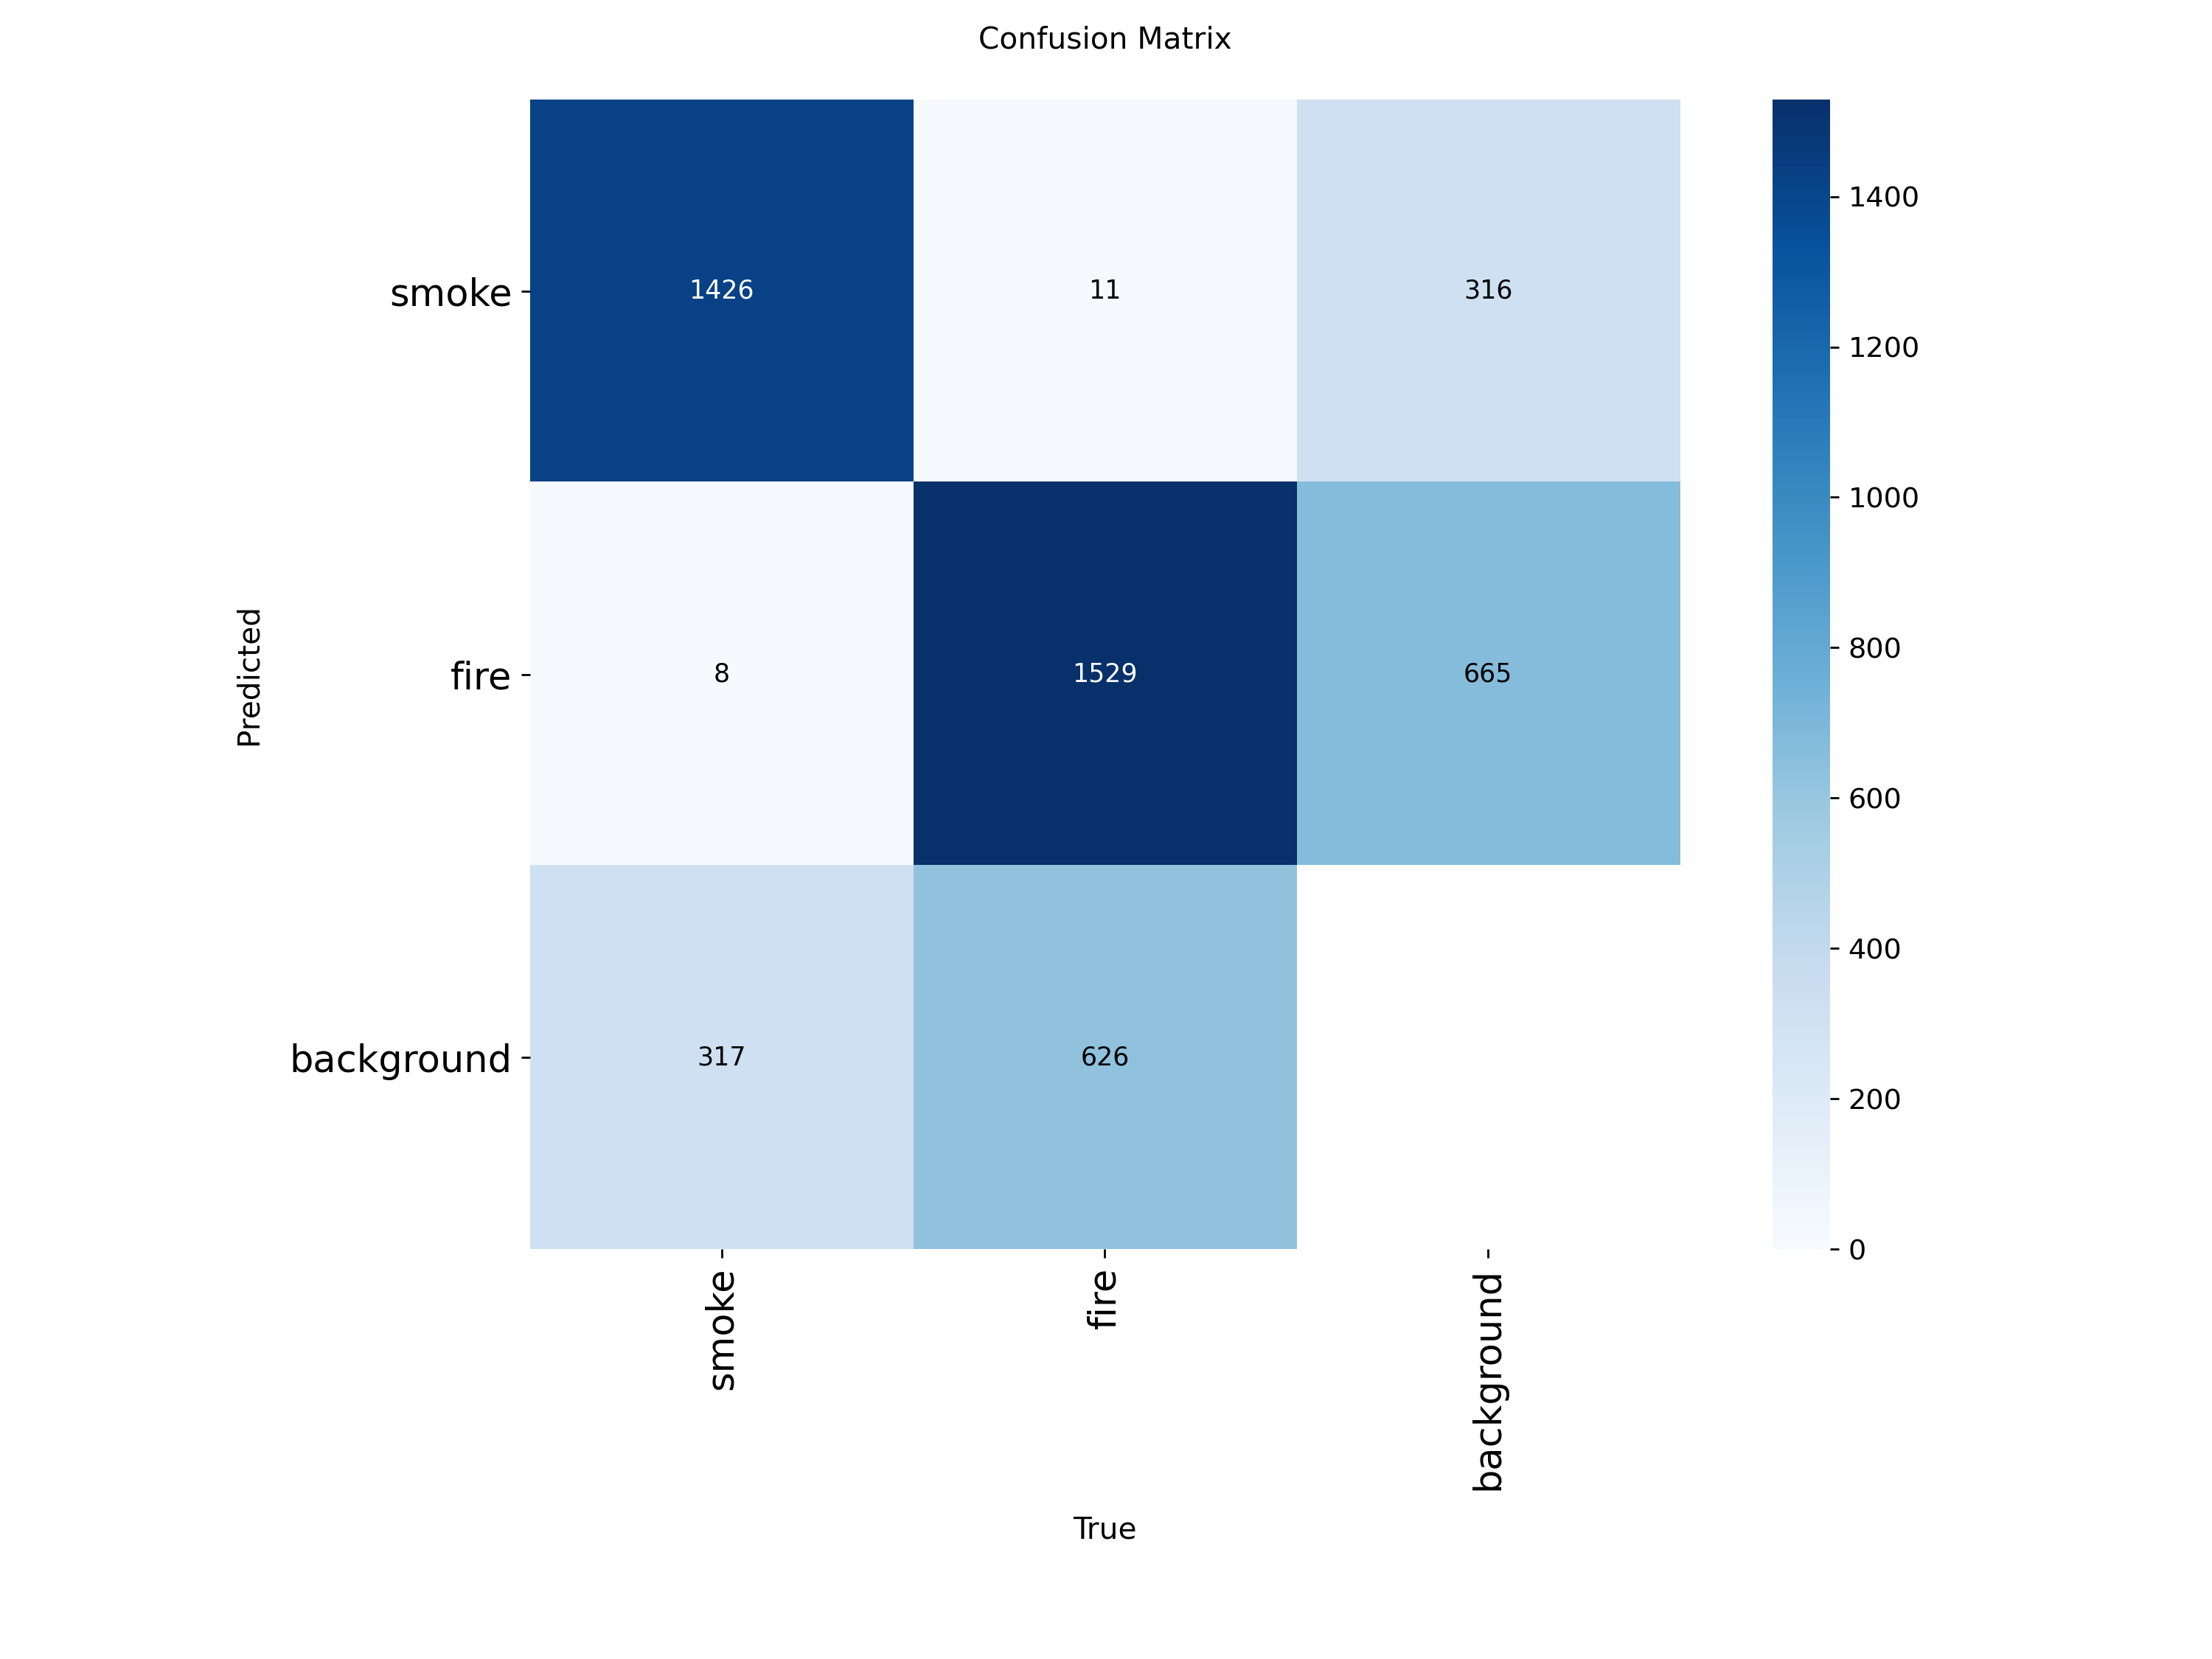


 confusion_matrix_normalized.png


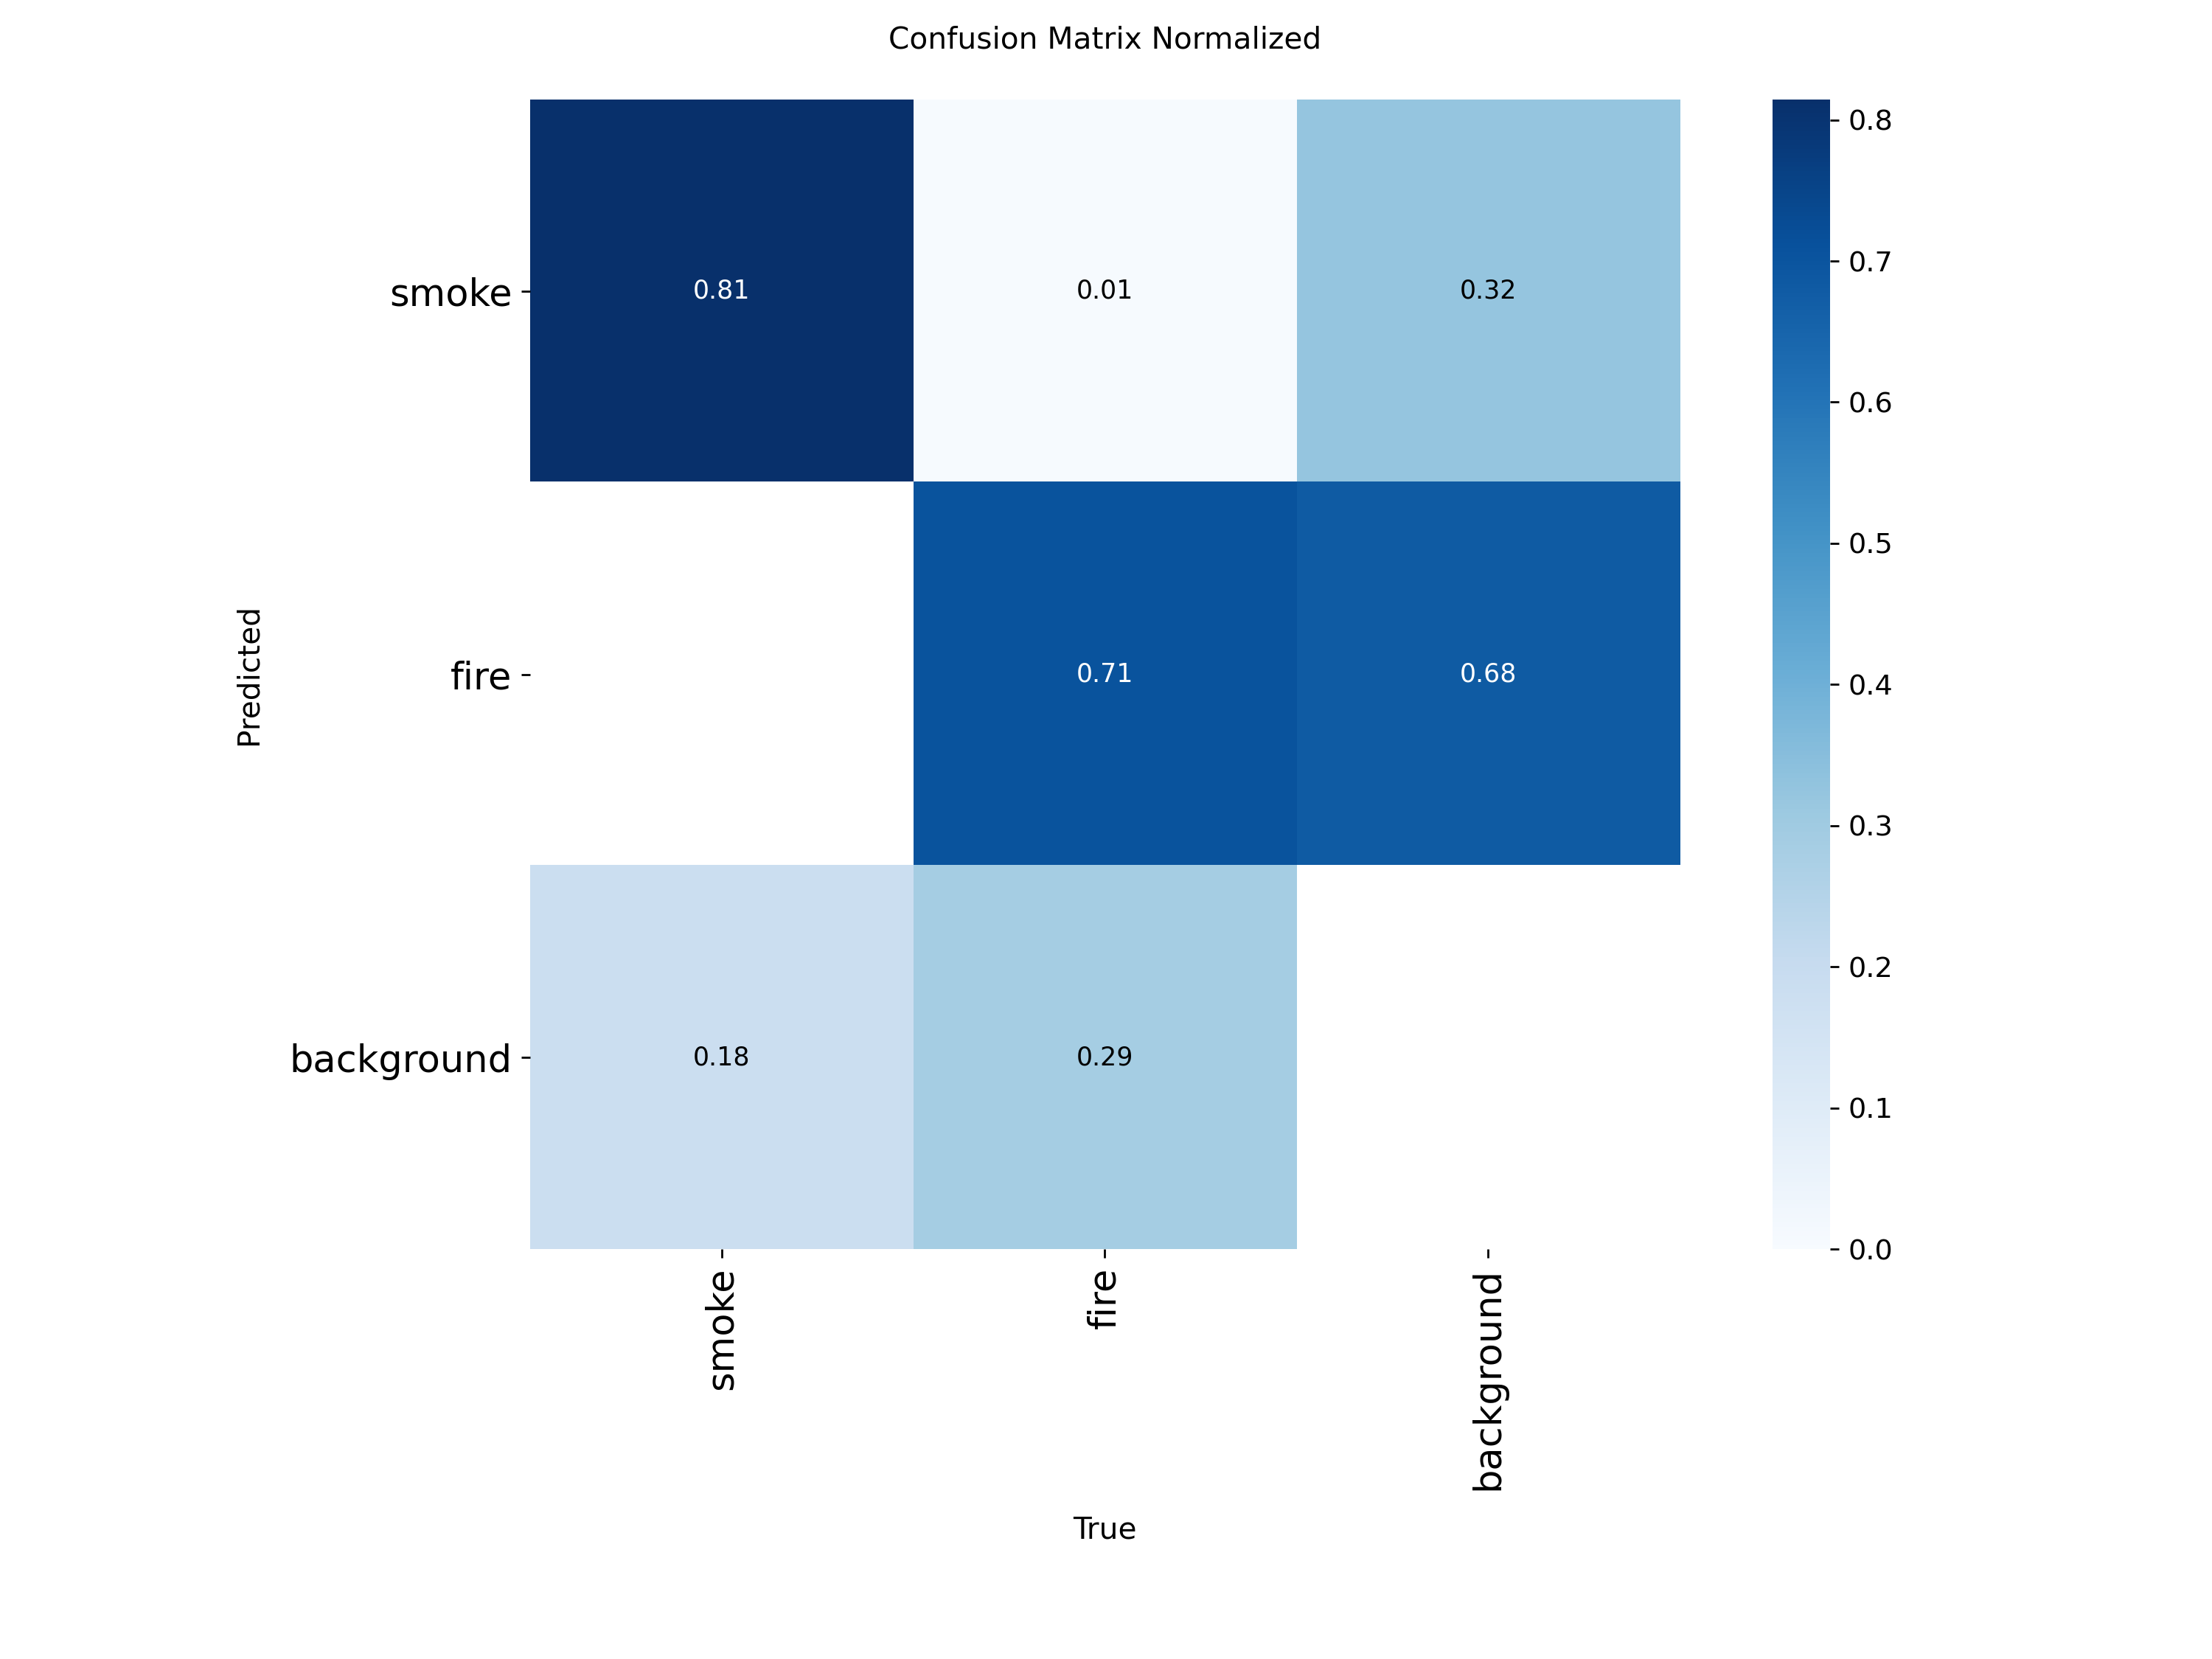

No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/PR_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/F1_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/P_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/R_curve.png


In [28]:
# ============================================================
# Visualización de resultados de validación
# ============================================================

from IPython.display import Image, display

plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for img_name in plots:

    img_path = VAL_DIR / img_name

    if img_path.exists():
        print("\n", img_name)
        display(Image(filename=str(img_path)))

    else:
        print("No encontrado:", img_path)

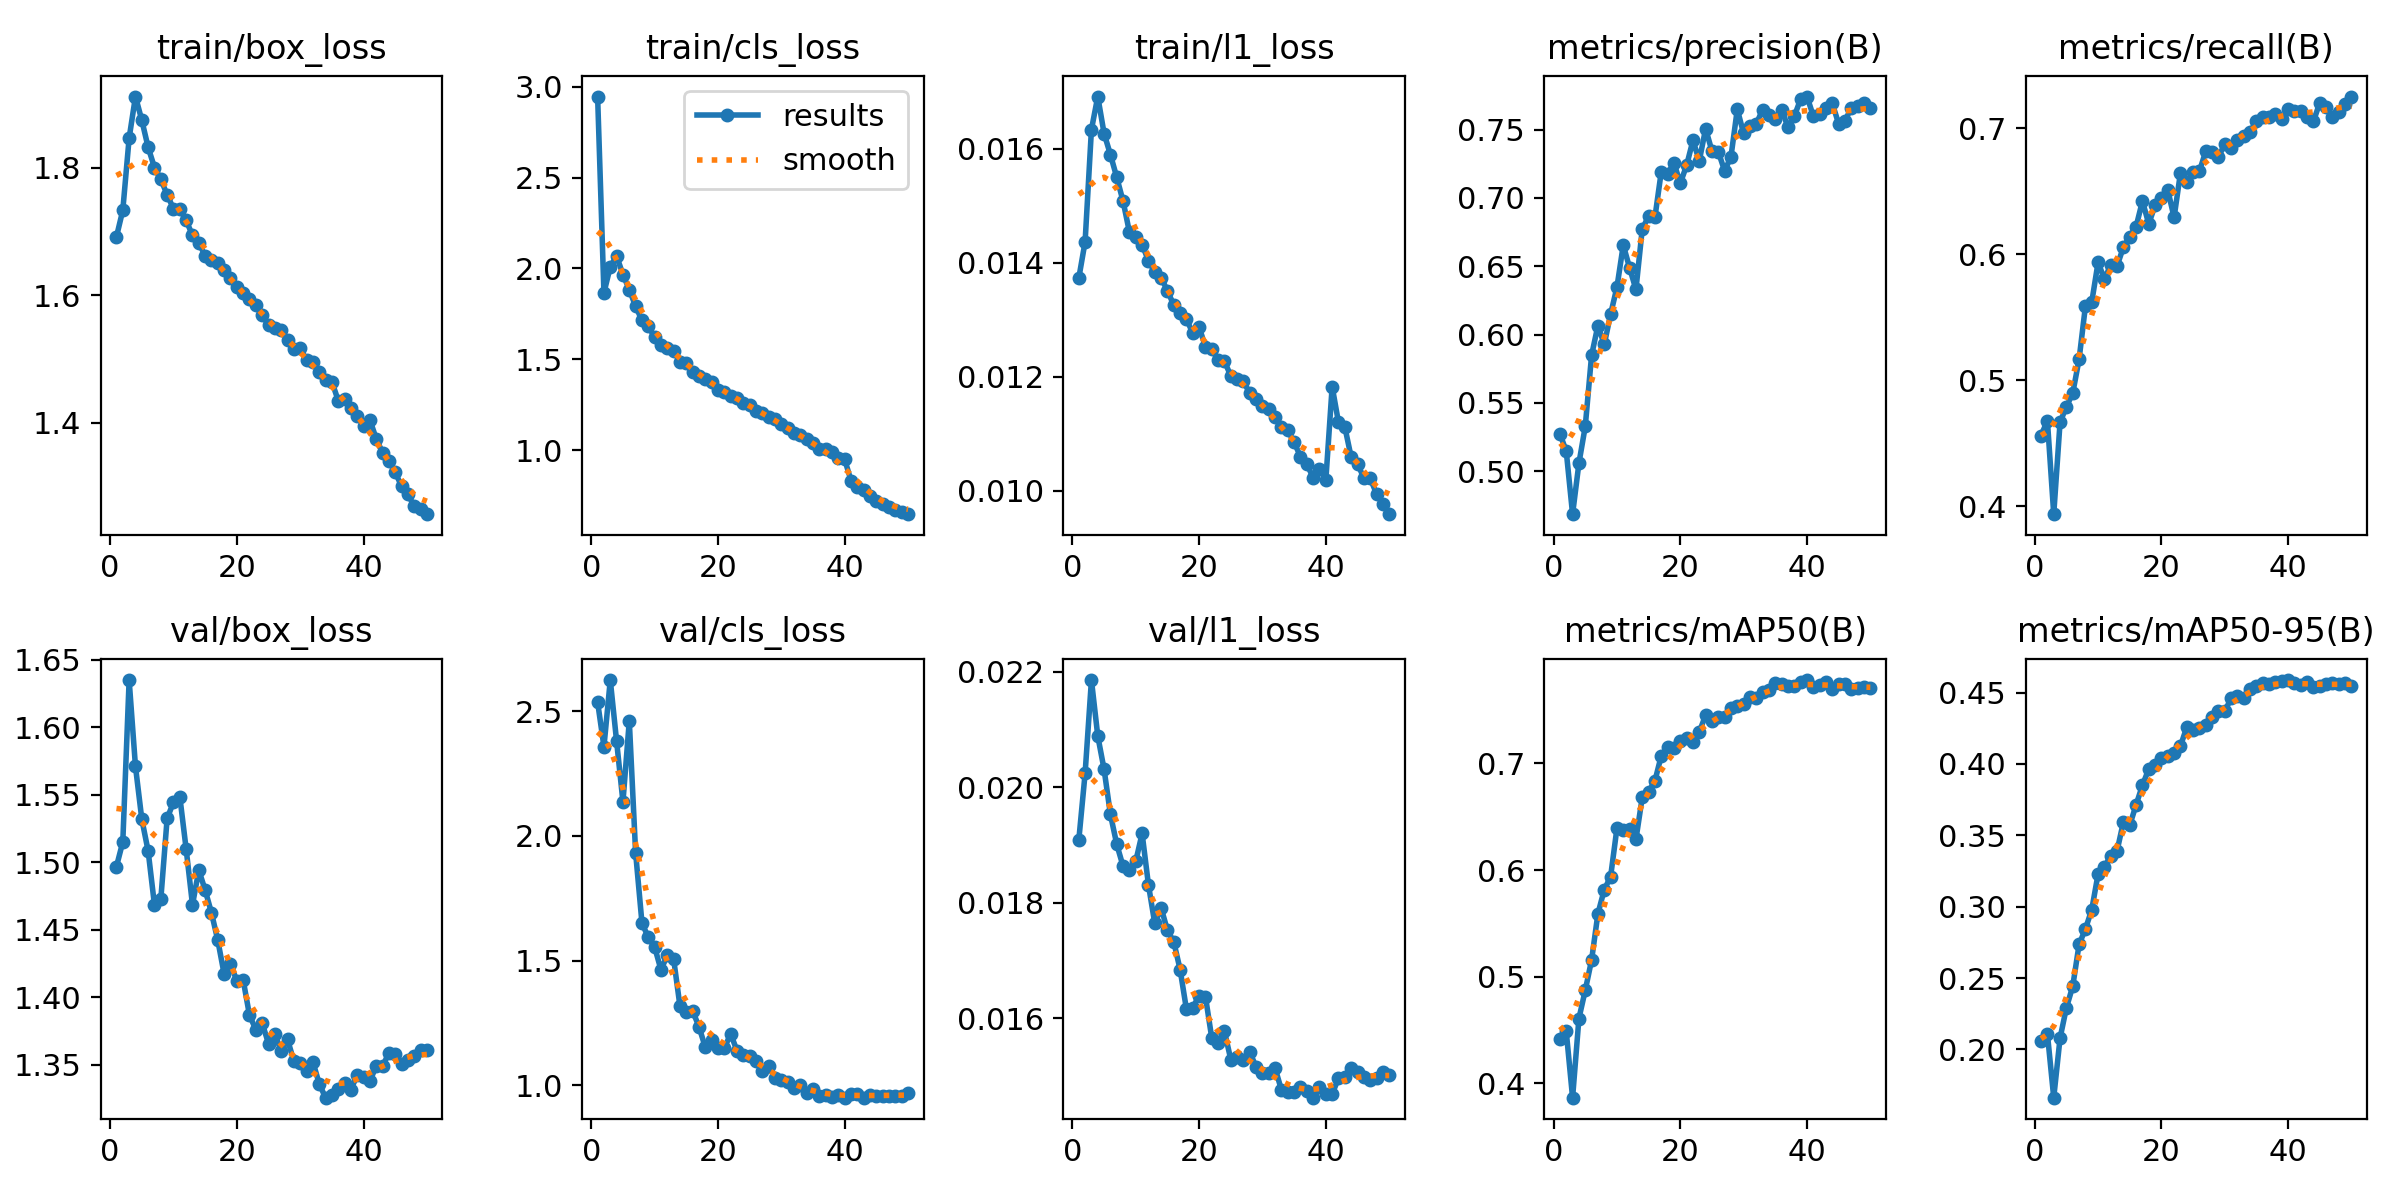

In [29]:
# ============================================================
# Curvas de entrenamiento
# ============================================================

RESULTS_PLOT = RUN_DIR / "results.png"

if RESULTS_PLOT.exists():
    display(Image(filename=str(RESULTS_PLOT)))
else:
    print("No encontrado:", RESULTS_PLOT)

In [30]:
# ============================================================
# Carpeta de resultados dentro del repositorio
# ============================================================

REPORTS_RESULTS_DIR = (
    PROJECT_DIR
    / "reports"
    / "results"
    / EXP_NAME
)

REPORTS_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Resultados del repositorio:")
print(REPORTS_RESULTS_DIR)

Resultados del repositorio:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline


In [31]:
# ============================================================
# Copia de artefactos relevantes al repositorio
# ============================================================

# ------------------------------------------------------------
# Artefactos del entrenamiento
# ------------------------------------------------------------

training_files = [
    "results.csv",
    "results.png",
]

for filename in training_files:

    src = RUN_DIR / filename
    dst = REPORTS_RESULTS_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        print("Copiado:", dst)
    else:
        print("No encontrado:", src)


# ------------------------------------------------------------
# Artefactos de validación
# ------------------------------------------------------------

validation_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for filename in validation_files:

    src = VAL_DIR / filename
    dst = REPORTS_RESULTS_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        print("Copiado:", dst)
    else:
        print("No encontrado:", src)

Copiado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/results.csv
Copiado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/results.png
Copiado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/confusion_matrix.png
Copiado: /content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/confusion_matrix_normalized.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/PR_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/F1_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/P_curve.png
No encontrado: /content/drive/MyDrive/VCII_DFire/runs/yolo26s_baseline_val/R_curve.png


In [32]:
# ============================================================
# Guardado del resumen de métricas
# ============================================================

METRICS_SUMMARY_PATH = (
    REPORTS_RESULTS_DIR
    / "metrics_summary.csv"
)

metrics_summary.to_csv(
    METRICS_SUMMARY_PATH,
    index=False
)

print("Resumen de métricas guardado en:")
print(METRICS_SUMMARY_PATH)

Resumen de métricas guardado en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/metrics_summary.csv


In [33]:
# ============================================================
# Registro de la configuración utilizada
# ============================================================

USED_CONFIG_PATH = (
    REPORTS_RESULTS_DIR
    / "experiment_config_used.yaml"
)

with open(
    USED_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    yaml.safe_dump(
        config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("Configuración utilizada guardada en:")
print(USED_CONFIG_PATH)

Configuración utilizada guardada en:
/content/VpC2---Deteccion-de-humo-y-fuego/reports/results/yolo26s_baseline/experiment_config_used.yaml


In [34]:
# ============================================================
# Verificación final de artefactos
# ============================================================

print(f"Artefactos registrados para {EXP_NAME}:\n")

for file in sorted(REPORTS_RESULTS_DIR.iterdir()):

    size_mb = file.stat().st_size / (1024 ** 2)

    print(
        f"{file.name:40s}"
        f"{size_mb:8.2f} MB"
    )

Artefactos registrados para yolo26s_baseline:

confusion_matrix.png                        0.11 MB
confusion_matrix_normalized.png             0.11 MB
experiment_config_used.yaml                 0.00 MB
metrics_summary.csv                         0.00 MB
results.csv                                 0.01 MB
results.png                                 0.26 MB


In [35]:
# ============================================================
# Estado del repositorio antes del commit
# ============================================================

%cd {PROJECT_DIR}

print("Branch actual:")
!git branch --show-current

print("\nEstado:")
!git status -sb

/content/VpC2---Deteccion-de-humo-y-fuego
Branch actual:
yolo26

Estado:
## yolo26...origin/yolo26
?? configs/experiments/yolo26s_baseline.yaml
?? reports/results/yolo26s_baseline/


In [36]:
# ============================================================
# Estado del repositorio antes del commit
# ============================================================

%cd {PROJECT_DIR}

print("Branch actual:")
!git branch --show-current

print("\nEstado:")
!git status -sb

/content/VpC2---Deteccion-de-humo-y-fuego
Branch actual:
yolo26

Estado:
## yolo26...origin/yolo26
?? configs/experiments/yolo26s_baseline.yaml
?? reports/results/yolo26s_baseline/
